# phase_0 depedency 


In [1]:
import torch, sys, subprocess
print("Python:", sys.version)
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print(subprocess.run(["nvidia-smi", "--query-gpu=name,driver_version,memory.total", "--format=csv"], capture_output=True, text=True).stdout)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128 | CUDA available: True
name, driver_version, memory.total [MiB]
Tesla P100-PCIE-16GB, 580.159.04, 16384 MiB



In [2]:
!git clone --depth 1 https://github.com/tusen-ai/Anchor3DLane.git /kaggle/working/Anchor3DLane

Cloning into '/kaggle/working/Anchor3DLane'...
remote: Enumerating objects: 359, done.
remote: Counting objects: 100% (359/359), done.
remote: Compressing objects: 100% (332/332), done.
remote: Total 359 (delta 31), reused 255 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (359/359), 5.19 MiB | 13.77 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [3]:
!wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /tmp/miniconda.sh
!bash /tmp/miniconda.sh -b -p /kaggle/working/miniconda3

PREFIX=/kaggle/working/miniconda3
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /kaggle/working/miniconda3


In [4]:
!/kaggle/working/miniconda3/bin/conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!/kaggle/working/miniconda3/bin/conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [5]:
!/kaggle/working/miniconda3/bin/conda create -y -n lane3d python=3.9

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /kaggle/working/miniconda3/envs/lane3d

  added / updated specs:
    - python=3.9


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.7.16  |       h06a4308_0         106 KB
    libnsl-2.0.0               |       h5eee18b_0          31 KB
    pip-26.0.1                 |     pyhc872135_1         1.1 MB
    python-3.9.25              |       h0dcde21_1        23.0 MB
    setuptools-80.9.0          |   py39h06a4308_0         1.4 MB
    tzdata-2026c               |       he532380_0         117 KB
    wheel-0.45.1               |   py39h06a4308_0         114 KB
    ------------------------------------------------------------
                                           Total:        25

In [6]:
!/kaggle/working/miniconda3/envs/lane3d/bin/pip install torch==1.9.1+cu111 torchvision==0.10.1+cu111 -f https://download.pytorch.org/whl/torch_stable.html

Looking in links: https://download.pytorch.org/whl/torch_stable.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 GB 12.0 MB/s  0:00:276m0:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 25.3 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 111.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 144.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [torchvision] [torchvision]


In [7]:
!/kaggle/working/miniconda3/envs/lane3d/bin/python -c "import torch; print(torch.__version__, torch.version.cuda, torch.cuda.is_available())"


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<string>", line 1, in <module>
  File "/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/torch/__init__.py", line 629, in <module>
    from .functional import *  # noqa: F403
  File "/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/torch/functional.py", line 6, in <module>
    import torch.nn.functional as F
  File "/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/torch/nn/__init__.py", line 1, in <module>
    from .modules import *  # noqa: F403
  File "/kaggle/

In [8]:
!cd /kaggle/working/Anchor3DLane && sed -i \
  -e 's/opencv_python==4.1.2.30/opencv_python==4.5.5.64/' \
  -e 's/scipy==1.4.1/scipy==1.7.3/' \
  -e 's/^tensorflow==2.4.0/# tensorflow==2.4.0  # deferred - only needed for tfrecord conversion/' \
  requirements.txt

!cd /kaggle/working/Anchor3DLane && /kaggle/working/miniconda3/envs/lane3d/bin/pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 110.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 120.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 MB 131.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 10.6 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 114.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 106.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.8/39.8 MB 115.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 80.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 95.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.6 MB/s  0:00:00
  Attempting uninstall: Pillow0m╺━━━━━━━━━━━━━━━━━━━━━━━━  9/24 [protobuf]
    Found existing installation: pillow 11.3.0━━━━━━━━━━━━━━━━  9/24 [protobuf]
    Uninstalling pillow-11.3.0:0m━━━━━━━━━━━━━━━━━━━━━━━━ 

In [9]:
!/kaggle/working/miniconda3/envs/lane3d/bin/pip install -U openmim
!/kaggle/working/miniconda3/envs/lane3d/bin/pip install mmcv-full==1.6.2 -f https://download.openmmlab.com/mmcv/dist/cu111/torch1.9.0/index.html

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.8/750.8 kB 24.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.1/953.1 kB 32.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 109.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 78.1 MB/s  0:00:00
  Created wheel for oss2: filename=oss2-2.17.0-py3-none-any.whl size=112465 sha256=4eb645c185af7a741f9a965b8a492e1845d9f3b14069063178040eb0e7113d40
  Stored in directory: /root/.cache/pip/wheels/4b/23/be/4682480f462d

In [10]:
!/kaggle/working/miniconda3/envs/lane3d/bin/pip install geffnet

In [11]:
!cd /kaggle/working/Anchor3DLane && /kaggle/working/miniconda3/envs/lane3d/bin/python setup.py develop
!grep -i anchor3dlane /kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/easy-install.pth

running develop
/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/setuptools/command/easy_install.py:156: EasyInstallDeprecationWarning: easy_install command is deprecated. Use build and pip and other standards-based tools.
  warnings.warn(
/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/setuptools/command/install.py:34: SetuptoolsDeprecationWarning: setup.py install is deprecated. Use build and pip and other standards-based tools.
  warnings.warn(
running egg_info
creating mmsegmentation.egg-info
writing manifest file 'mmsegmentation.egg-info/SOURCES.txt'
writing manifest file 'mmsegmentation.egg-info/SOURCES.txt'
running build_ext
/kaggle/working/Anchor3DLane


In [12]:
!grep -i anchor3dlane /kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/easy-install.pth

/kaggle/working/Anchor3DLane


In [13]:
!cat /kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/mmsegmentation.egg-link 2>&1
!/kaggle/working/miniconda3/envs/lane3d/bin/python -c "import mmseg; print(mmseg.__file__)"

/kaggle/working/Anchor3DLane
./kaggle/working/Anchor3DLane/mmseg/__init__.py


In [14]:
import os
os.environ["TORCH_CUDA_ARCH_LIST"] = "6.0"  
%cd /kaggle/working/Anchor3DLane/mmseg/models/utils/ops

/kaggle/working/Anchor3DLane/mmseg/models/utils/ops


In [15]:
!grep -n "ONCEDataset" /kaggle/working/Anchor3DLane/mmseg/datasets/__init__.py

25:from .lane_datasets.once import ONCEDataset
35:    'OpenlaneMFDataset', 'ONCEDataset']


In [16]:
!cd /kaggle/working/Anchor3DLane && sed -i \
  -e "s/^from .lane_datasets.once import ONCEDataset/# from .lane_datasets.once import ONCEDataset  # deferred - needs private 'jarvis' package/" \
  -e "s/'ONCEDataset'\]/]/" \
  mmseg/datasets/__init__.py

In [17]:
!grep -n "^import\|^from" /kaggle/working/Anchor3DLane/tools/convert_datasets/openlane.py | head -20

1:import os
2:import json
3:import re
4:import cv2
5:from mmseg.datasets.tools.utils import *
6:from scipy.optimize import curve_fit
7:from scipy.interpolate import interp1d
8:import numpy as np
9:import matplotlib.pyplot as plt
10:import tqdm
11:import mmcv
12:import pickle
13:import argparse
14:import glob


In [18]:
!sed -i '1i from ortools.graph import pywrapgraph  # MUST be first - see Phase 0 notes on Abseil double-registration segfault' /kaggle/working/Anchor3DLane/tools/convert_datasets/openlane.py
!head -3 /kaggle/working/Anchor3DLane/tools/convert_datasets/openlane.py

from ortools.graph import pywrapgraph  # MUST be first - see Phase 0 notes on Abseil double-registration segfault
import os
import json


# phase_1 datalaod and see can convert to tensor

In [19]:
!mkdir -p /kaggle/working/data/OpenLane

In [20]:
!rm /kaggle/working/data/OpenLane/lane3d_1000
!rm /kaggle/working/data/OpenLane/images
!ln -s /kaggle/input/datasets/shivamchaudharys/openlane-3d-mini/lane3d_300 /kaggle/working/data/OpenLane/lane3d_1000
!ln -s /kaggle/input/datasets/shivamchaudharys/openlane-image/images /kaggle/working/data/OpenLane/images
!ls -la /kaggle/working/data/OpenLane/

rm: cannot remove '/kaggle/working/data/OpenLane/lane3d_1000': No such file or directory
rm: cannot remove '/kaggle/working/data/OpenLane/images': No such file or directory
total 16
drwxr-xr-x 2 root root 4096 Jul 20 09:30 .
drwxr-xr-x 3 root root 4096 Jul 20 09:30 ..
lrwxrwxrwx 1 root root   61 Jul 20 09:30 images -> /kaggle/input/datasets/shivamchaudharys/openlane-image/images
lrwxrwxrwx 1 root root   67 Jul 20 09:30 lane3d_1000 -> /kaggle/input/datasets/shivamchaudharys/openlane-3d-mini/lane3d_300


In [21]:
!ls /kaggle/working/data/OpenLane/lane3d_1000/training | head -5
!ls /kaggle/working/data/OpenLane/lane3d_1000/training | wc -l
!ls /kaggle/working/data/OpenLane/images/training | wc -l

segment-10017090168044687777_6380_000_6400_000_with_camera_labels
segment-1005081002024129653_5313_150_5333_150_with_camera_labels
segment-10072231702153043603_5725_000_5745_000_with_camera_labels
segment-10082223140073588526_6140_000_6160_000_with_camera_labels
segment-10096619443888687526_2820_000_2840_000_with_camera_labels
ls: write error: Broken pipe
240
798


In [22]:
!rm -f /kaggle/working/data/OpenLane/data_splits/training.json /kaggle/working/data/OpenLane/data_splits/validation.json
!cd /kaggle/working/Anchor3DLane && /kaggle/working/miniconda3/envs/lane3d/bin/python tools/convert_datasets/openlane.py /kaggle/working/data/OpenLane --merge
!wc -c /kaggle/working/data/OpenLane/data_splits/training.json
!wc -c /kaggle/working/data/OpenLane/data_splits/validation.json

6745813861 /kaggle/working/data/OpenLane/data_splits/training.json
1986039149 /kaggle/working/data/OpenLane/data_splits/validation.json


In [23]:
!cd /kaggle/working/Anchor3DLane && /kaggle/working/miniconda3/envs/lane3d/bin/python tools/convert_datasets/openlane.py /kaggle/working/data/OpenLane --generate

0it [00:00, ?it/s]image_id 1 1
image_id 2 2
2it [00:00, 12.94it/s]image_id 3 3
image_id 4 4
4it [00:00, 10.89it/s]image_id 5 5
image_id 6 6
image_id 7 7
7it [00:00, 12.95it/s]image_id 8 8
image_id 9 9
9it [00:00, 14.43it/s]image_id 10 10
image_id 11 11
image_id 12 12
12it [00:00, 16.23it/s]image_id 13 13
image_id 14 14
14it [00:00, 15.05it/s]image_id 15 15
image_id 16 16
16it [00:01, 15.91it/s]image_id 17 17
image_id 18 18
18it [00:01, 16.56it/s]image_id 19 19
image_id 20 20
20it [00:01, 15.53it/s]image_id 21 21
image_id 22 22
22it [00:01, 14.46it/s]image_id 23 23
image_id 24 24
24it [00:01, 15.56it/s]image_id 25 25
image_id 26 26
26it [00:01, 14.47it/s]image_id 27 27
image_id 28 28
image_id 29 29
image_id 30 30
30it [00:01, 17.08it/s]image_id 31 31
image_id 32 32
32it [00:02, 15.86it/s]image_id 33 33
image_id 34 34
34it [00:02, 13.92it/s]image_id 35 35
image_id 36 36
36it [00:02, 14.97it/s]image_id 37 37
image_id 38 38
38it [00:02, 15.94it/s]image_id 39 39
image_id 40 40
40it [00:02, 

In [24]:
!ls -la /kaggle/working/data/OpenLane/cache_dense/ | head -5
!ls /kaggle/working/data/OpenLane/cache_dense/ | wc -l
!ls -la /kaggle/working/data/OpenLane/data_lists/

total 52
drwxr-xr-x   4 root root  4096 Jul 20 11:50 .
drwxr-xr-x   5 root root  4096 Jul 20 11:20 ..
drwxr-xr-x 282 root root 36864 Jul 20 11:50 training
drwxr-xr-x  22 root root  4096 Jul 20 11:50 validation
2
total 4468
drwxr-xr-x 2 root root    4096 Jul 20 11:50 .
drwxr-xr-x 5 root root    4096 Jul 20 11:20 ..
-rw-r--r-- 1 root root 4190941 Jul 20 11:21 training.txt
-rw-r--r-- 1 root root  370665 Jul 20 11:50 validation.txt


In [27]:
%%writefile /kaggle/working/test_dataset_fixed.py
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ortools.graph import pywrapgraph

from mmseg.datasets.builder import build_dataset

anchor_y_steps = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
img_norm_cfg = dict(mean=[123.675, 116.28, 103.53], std=[58.395, 57.12, 57.375], to_rgb=True)
input_size = (360, 480)

test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='Resize', img_scale=(input_size[1], input_size[0]), keep_ratio=False),
    dict(type='Normalize', **img_norm_cfg),
    dict(type='MaskGenerate', input_size=input_size),
    dict(type='LaneFormat'),
    dict(type='Collect', keys=['img', 'img_metas', 'gt_3dlanes', 'gt_project_matrix', 'mask']),
]

dataset_cfg = dict(
    type='OpenlaneDataset',
    data_root='/kaggle/working/data/OpenLane',
    data_list='validation.txt',
    dataset_config=dict(max_lanes=25, input_size=input_size),
    y_steps=anchor_y_steps,
    test_mode=True,
    pipeline=test_pipeline,
)

dataset = build_dataset(dataset_cfg)
print(f"dataset length: {len(dataset)}", flush=True)

sample = dataset[0]
img = sample['img'].data          # unwrap DataContainer
gt_3dlanes = sample['gt_3dlanes'].data
mask = sample['mask'].data

print("img shape:", img.shape, flush=True)
print("gt_3dlanes shape:", gt_3dlanes.shape, flush=True)
print("mask shape:", mask.shape, flush=True)
print("img dtype/range:", img.dtype, img.min().item(), img.max().item(), flush=True)

print("PHASE 1 COMPLETE - dataset pipeline verified end to end", flush=True)

Writing /kaggle/working/test_dataset_fixed.py


In [28]:
!/kaggle/working/miniconda3/envs/lane3d/bin/python /kaggle/working/test_dataset_fixed.py

is_resample: True
Now loading annotations...
after load annotation
find 3904 samples in /kaggle/working/data/OpenLane/data_lists/validation.txt.
dataset length: 3904
img shape: torch.Size([3, 360, 480])
gt_3dlanes shape: torch.Size([20, 605])
mask shape: torch.Size([1, 360, 480])
img dtype/range: torch.float32 -2.032280206680298 2.640000104904175
PHASE 1 COMPLETE - dataset pipeline verified end to end


# phase 2


In [29]:
!head -1 /kaggle/working/Anchor3DLane/tools/train.py | grep -q pywrapgraph || \
  sed -i '1i from ortools.graph import pywrapgraph  # MUST be first - Abseil double-registration segfault fix' /kaggle/working/Anchor3DLane/tools/train.py
!head -3 /kaggle/working/Anchor3DLane/tools/train.py

from ortools.graph import pywrapgraph  # MUST be first - Abseil double-registration segfault fix
# Copyright (c) OpenMMLab. All rights reserved.
import argparse


In [31]:
%%writefile /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_smoketest.py
# Phase 2 smoke-test config.
# Inherits everything from the real training config, overrides only
# what needs to shrink for a fast correctness check.
_base_ = './anchor3dlane.py'

data_root = '/kaggle/working/data/OpenLane'
data = dict(
    samples_per_gpu=4,      # smaller than the real 16 — safer first run, less to debug if OOM
    workers_per_gpu=2,
    train=dict(data_root=data_root),
    test=dict(data_root=data_root),
)

# drastically shrunk schedule — this is a correctness check, not a real run
runner = dict(type='IterBasedRunner', max_iters=20)
checkpoint_config = dict(by_epoch=False, interval=10)   # save at iter 10 AND iter 20
log_config = dict(interval=1)   # log every iteration so we can watch loss move
work_dir = '/kaggle/working/output/smoketest'

Writing /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_smoketest.py


In [32]:
!cat /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_smoketest.py

# Phase 2 smoke-test config.
# Inherits everything from the real training config, overrides only
# what needs to shrink for a fast correctness check.
_base_ = './anchor3dlane.py'

data_root = '/kaggle/working/data/OpenLane'
data = dict(
    samples_per_gpu=4,      # smaller than the real 16 — safer first run, less to debug if OOM
    workers_per_gpu=2,
    train=dict(data_root=data_root),
    test=dict(data_root=data_root),
)

# drastically shrunk schedule — this is a correctness check, not a real run
runner = dict(type='IterBasedRunner', max_iters=20)
checkpoint_config = dict(by_epoch=False, interval=10)   # save at iter 10 AND iter 20
log_config = dict(interval=1)   # log every iteration so we can watch loss move
work_dir = '/kaggle/working/output/smoketest'


In [33]:
!cd /kaggle/working/Anchor3DLane && /kaggle/working/miniconda3/envs/lane3d/bin/python tools/train.py configs/openlane/anchor3dlane_smoketest.py

Traceback (most recent call last):
  File "/kaggle/working/Anchor3DLane/tools/train.py", line 24, in <module>
    from mmseg.apis import init_random_seed, set_random_seed
  File "/kaggle/working/Anchor3DLane/mmseg/apis/__init__.py", line 2, in <module>
    from .inference import inference_segmentor, init_segmentor, show_result_pyplot
  File "/kaggle/working/Anchor3DLane/mmseg/apis/inference.py", line 2, in <module>
    import matplotlib.pyplot as plt
  File "/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/matplotlib/pyplot.py", line 2230, in <module>
    switch_backend(rcParams["backend"])
  File "/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/matplotlib/pyplot.py", line 267, in switch_backend
    class backend_mod(matplotlib.backend_bases._Backend):
  File "/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/matplotlib/pyplot.py", line 268, in backend_mod
    locals().update(vars(importlib.import_module(backend_name)))
  File "/kag

In [34]:
!MPLBACKEND=Agg /kaggle/working/miniconda3/envs/lane3d/bin/python -c "import matplotlib.pyplot; print('matplotlib ok with Agg backend')"

matplotlib ok with Agg backend


In [35]:
!cd /kaggle/working/Anchor3DLane && MPLBACKEND=Agg /kaggle/working/miniconda3/envs/lane3d/bin/python tools/train.py configs/openlane/anchor3dlane_smoketest.py

Traceback (most recent call last):
  File "/kaggle/working/Anchor3DLane/mmseg/models/utils/ops/functions/ms_deform_attn_func.py", line 22, in <module>
    import MultiScaleDeformableAttention as MSDA
ModuleNotFoundError: No module named 'MultiScaleDeformableAttention'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/kaggle/working/Anchor3DLane/tools/train.py", line 24, in <module>
    from mmseg.apis import init_random_seed, set_random_seed
  File "/kaggle/working/Anchor3DLane/mmseg/apis/__init__.py", line 2, in <module>
    from .inference import inference_segmentor, init_segmentor, show_result_pyplot
  File "/kaggle/working/Anchor3DLane/mmseg/apis/inference.py", line 9, in <module>
    from mmseg.models import build_segmentor
  File "/kaggle/working/Anchor3DLane/mmseg/models/__init__.py", line 2, in <module>
    from .backbones import *  # noqa: F401,F403
  File "/kaggle/working/Anchor3DLane/mmseg/models/backbones/__ini

In [37]:
import os
os.environ["TORCH_CUDA_ARCH_LIST"] = "6.0"  # confirm this session's GPU first with nvidia-smi
%cd /kaggle/working/Anchor3DLane/mmseg/models/utils/ops

/kaggle/working/Anchor3DLane/mmseg/models/utils/ops


In [38]:
!/kaggle/working/miniconda3/envs/lane3d/bin/python setup.py build install

running build
running build_py
creating build
creating build/lib.linux-x86_64-3.9
creating build/lib.linux-x86_64-3.9/functions
copying functions/ms_deform_attn_func.py -> build/lib.linux-x86_64-3.9/functions
copying functions/__init__.py -> build/lib.linux-x86_64-3.9/functions
creating build/lib.linux-x86_64-3.9/modules
copying modules/__init__.py -> build/lib.linux-x86_64-3.9/modules
copying modules/ms_deform_attn.py -> build/lib.linux-x86_64-3.9/modules
running build_ext
creating /kaggle/working/Anchor3DLane/mmseg/models/utils/ops/build/temp.linux-x86_64-3.9
creating /kaggle/working/Anchor3DLane/mmseg/models/utils/ops/build/temp.linux-x86_64-3.9/kaggle
creating /kaggle/working/Anchor3DLane/mmseg/models/utils/ops/build/temp.linux-x86_64-3.9/kaggle/working
creating /kaggle/working/Anchor3DLane/mmseg/models/utils/ops/build/temp.linux-x86_64-3.9/kaggle/working/Anchor3DLane
creating /kaggle/working/Anchor3DLane/mmseg/models/utils/ops/build/temp.linux-x86_64-3.9/kaggle/working/Anchor3DLan

In [40]:
!/kaggle/working/miniconda3/envs/lane3d/bin/pip install "yapf==0.32.0"

  Attempting uninstall: yapf
    Found existing installation: yapf 0.43.0
    Uninstalling yapf-0.43.0:
      Successfully uninstalled yapf-0.43.0


In [42]:
!mkdir -p /kaggle/working/Anchor3DLane/pretrained
!wget -q https://download.openmmlab.com/pretrain/third_party/resnet18_v1c-b5776b93.pth -O /kaggle/working/Anchor3DLane/pretrained/resnet18_v1c-b5776b93.pth
!ls -lh /kaggle/working/Anchor3DLane/pretrained/

total 45M
-rw-r--r-- 1 root root 45M Nov  2  2021 resnet18_v1c-b5776b93.pth


In [44]:
!cd /kaggle/working/Anchor3DLane && sed -i "/dict(type='TensorboardLoggerHook')/d; s/dict(type='TextLoggerHook', by_epoch=False),/dict(type='TextLoggerHook', by_epoch=False)/" configs/openlane/anchor3dlane_smoketest.py

In [45]:
!cat /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_smoketest.py

# Phase 2 smoke-test config.
# Inherits everything from the real training config, overrides only
# what needs to shrink for a fast correctness check.
_base_ = './anchor3dlane.py'

data_root = '/kaggle/working/data/OpenLane'
data = dict(
    samples_per_gpu=4,      # smaller than the real 16 — safer first run, less to debug if OOM
    workers_per_gpu=2,
    train=dict(data_root=data_root),
    test=dict(data_root=data_root),
)

# drastically shrunk schedule — this is a correctness check, not a real run
runner = dict(type='IterBasedRunner', max_iters=20)
checkpoint_config = dict(by_epoch=False, interval=10)   # save at iter 10 AND iter 20
log_config = dict(interval=1)   # log every iteration so we can watch loss move
work_dir = '/kaggle/working/output/smoketest'


In [47]:
!/kaggle/working/miniconda3/envs/lane3d/bin/pip install tensorboard future

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 129.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 118.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [tensorboard] [tensorboard]


In [49]:
%%writefile /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_smoketest.py
_base_ = './anchor3dlane.py'

data_root = '/kaggle/working/data/OpenLane'
data = dict(
    samples_per_gpu=4,
    workers_per_gpu=2,
    train=dict(data_root=data_root),
    test=dict(data_root=data_root),
)

runner = dict(type='IterBasedRunner', max_iters=20)
checkpoint_config = dict(by_epoch=False, interval=10)
log_config = dict(
    interval=1,
    hooks=[dict(type='TextLoggerHook', by_epoch=False)]
)
work_dir = '/kaggle/working/output/smoketest'

Overwriting /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_smoketest.py


In [50]:
!cat /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_smoketest.py
!grep -c Tensorboard /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_smoketest.py

_base_ = './anchor3dlane.py'

data_root = '/kaggle/working/data/OpenLane'
data = dict(
    samples_per_gpu=4,
    workers_per_gpu=2,
    train=dict(data_root=data_root),
    test=dict(data_root=data_root),
)

runner = dict(type='IterBasedRunner', max_iters=20)
checkpoint_config = dict(by_epoch=False, interval=10)
log_config = dict(
    interval=1,
    hooks=[dict(type='TextLoggerHook', by_epoch=False)]
)
work_dir = '/kaggle/working/output/smoketest'
0


In [51]:
!cd /kaggle/working/Anchor3DLane && MPLBACKEND=Agg /kaggle/working/miniconda3/envs/lane3d/bin/python tools/train.py configs/openlane/anchor3dlane_smoketest.py

2026-07-20 12:39:09,470 - mmseg - INFO - Multi-processing start method is `None`
2026-07-20 12:39:09,470 - mmseg - INFO - OpenCV num_threads is `4
2026-07-20 12:39:09,536 - mmseg - INFO - Environment info:
------------------------------------------------------------
sys.platform: linux
Python: 3.9.25 (main, Nov  3 2025, 22:33:05) [GCC 11.2.0]
CUDA available: True
GPU 0: Tesla P100-PCIE-16GB
CUDA_HOME: /usr/local/cuda
NVCC: Cuda compilation tools, release 12.8, V12.8.93
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PyTorch: 1.9.1+cu111
PyTorch compiling details: PyTorch built with:
  - GCC 7.3
  - C++ Version: 201402
  - Intel(R) Math Kernel Library Version 2020.0.0 Product Build 20191122 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.1.2 (Git Hash 98be7e8afa711dc9b66c8ff3504129cb82013cdb)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.1
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;

In [52]:
!ls -la /kaggle/working/output/smoketest/

total 287376
drwxr-xr-x 2 root root      4096 Jul 20 12:39 .
drwxr-xr-x 3 root root      4096 Jul 20 12:30 ..
-rw-r--r-- 1 root root      8867 Jul 20 12:32 20260720_123239.log
-rw-r--r-- 1 root root     31935 Jul 20 12:34 20260720_123400.log
-rw-r--r-- 1 root root      2447 Jul 20 12:34 20260720_123400.log.json
-rw-r--r-- 1 root root     31936 Jul 20 12:36 20260720_123555.log
-rw-r--r-- 1 root root      2448 Jul 20 12:36 20260720_123555.log.json
-rw-r--r-- 1 root root     31936 Jul 20 12:37 20260720_123738.log
-rw-r--r-- 1 root root      2448 Jul 20 12:37 20260720_123738.log.json
-rw-r--r-- 1 root root     37274 Jul 20 12:39 20260720_123909.log
-rw-r--r-- 1 root root      7990 Jul 20 12:39 20260720_123909.log.json
-rw-r--r-- 1 root root      5767 Jul 20 12:39 anchor3dlane_smoketest.py
-rw-r--r-- 1 root root 147036545 Jul 20 12:39 iter_10.pth
-rw-r--r-- 1 root root 147036609 Jul 20 12:39 iter_20.pth
lrwxrwxrwx 1 root root        11 Jul 20 12:39 latest.pth -> iter_20.pth


In [53]:
!cd /kaggle/working/Anchor3DLane && MPLBACKEND=Agg /kaggle/working/miniconda3/envs/lane3d/bin/python tools/train.py configs/openlane/anchor3dlane_smoketest.py --resume-from /kaggle/working/output/smoketest/iter_10.pth

2026-07-20 12:42:54,954 - mmseg - INFO - Multi-processing start method is `None`
2026-07-20 12:42:54,955 - mmseg - INFO - OpenCV num_threads is `4
2026-07-20 12:42:55,011 - mmseg - INFO - Environment info:
------------------------------------------------------------
sys.platform: linux
Python: 3.9.25 (main, Nov  3 2025, 22:33:05) [GCC 11.2.0]
CUDA available: True
GPU 0: Tesla P100-PCIE-16GB
CUDA_HOME: /usr/local/cuda
NVCC: Cuda compilation tools, release 12.8, V12.8.93
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PyTorch: 1.9.1+cu111
PyTorch compiling details: PyTorch built with:
  - GCC 7.3
  - C++ Version: 201402
  - Intel(R) Math Kernel Library Version 2020.0.0 Product Build 20191122 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.1.2 (Git Hash 98be7e8afa711dc9b66c8ff3504129cb82013cdb)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.1
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;

In [54]:
%%writefile /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_real.py
_base_ = './anchor3dlane.py'

data_root = '/kaggle/working/data/OpenLane'
data = dict(
    samples_per_gpu=8,      # start here, not 16 — check memory before going higher
    workers_per_gpu=4,
    train=dict(data_root=data_root),
    test=dict(data_root=data_root),
)

runner = dict(type='IterBasedRunner', max_iters=60000)   # the real, full schedule
checkpoint_config = dict(by_epoch=False, interval=500)   # far more frequent than the default 5000 — see note below
log_config = dict(
    interval=20,
    hooks=[dict(type='TextLoggerHook', by_epoch=False)]
)
work_dir = '/kaggle/working/output/real_run'

Writing /kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_real.py


In [57]:
!sed -i "s/from mmcv.utils import Config, DictAction, get_git_hash, find_latest_checkpoint/from mmcv.utils import Config, DictAction, get_git_hash/" /kaggle/working/Anchor3DLane/tools/train.py
!sed -i "/from mmseg.utils import build_ddp, build_dp, get_device, setup_multi_processes, get_root_logger, collect_env/s/collect_env/collect_env, find_latest_checkpoint/" /kaggle/working/Anchor3DLane/tools/train.py
!grep -n "^from mmcv.utils import\|^from mmseg.utils import" /kaggle/working/Anchor3DLane/tools/train.py

20:from mmcv.utils import Config, DictAction, get_git_hash
27:from mmseg.utils import build_ddp, build_dp, get_device, setup_multi_processes, get_root_logger, collect_env, find_latest_checkpoint


In [58]:
!cd /kaggle/working/Anchor3DLane && MPLBACKEND=Agg /kaggle/working/miniconda3/envs/lane3d/bin/python tools/train.py configs/openlane/anchor3dlane_real.py --auto-resume

2026-07-20 12:50:33,192 - mmseg - INFO - Multi-processing start method is `None`
2026-07-20 12:50:33,193 - mmseg - INFO - OpenCV num_threads is `4
2026-07-20 12:50:33,251 - mmseg - INFO - Environment info:
------------------------------------------------------------
sys.platform: linux
Python: 3.9.25 (main, Nov  3 2025, 22:33:05) [GCC 11.2.0]
CUDA available: True
GPU 0: Tesla P100-PCIE-16GB
CUDA_HOME: /usr/local/cuda
NVCC: Cuda compilation tools, release 12.8, V12.8.93
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PyTorch: 1.9.1+cu111
PyTorch compiling details: PyTorch built with:
  - GCC 7.3
  - C++ Version: 201402
  - Intel(R) Math Kernel Library Version 2020.0.0 Product Build 20191122 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.1.2 (Git Hash 98be7e8afa711dc9b66c8ff3504129cb82013cdb)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.1
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;

In [92]:
!cd /kaggle/working/output/real_run && ls -1 iter_*.pth | sort -t_ -k2 -n | head -n -3 | xargs -r rm -v

removed 'iter_54000.pth'
removed 'iter_54500.pth'
removed 'iter_55000.pth'
removed 'iter_55500.pth'
removed 'iter_56000.pth'
removed 'iter_56500.pth'
removed 'iter_57000.pth'
removed 'iter_57500.pth'
removed 'iter_58000.pth'
removed 'iter_58500.pth'


In [84]:
!cd /kaggle/working/Anchor3DLane && MPLBACKEND=Agg /kaggle/working/miniconda3/envs/lane3d/bin/python tools/train.py configs/openlane/anchor3dlane_real.py --auto-resume

2026-07-20 18:42:26,418 - mmseg - INFO - Multi-processing start method is `None`
2026-07-20 18:42:26,419 - mmseg - INFO - OpenCV num_threads is `4
2026-07-20 18:42:26,525 - mmseg - INFO - Environment info:
------------------------------------------------------------
sys.platform: linux
Python: 3.9.25 (main, Nov  3 2025, 22:33:05) [GCC 11.2.0]
CUDA available: True
GPU 0: Tesla P100-PCIE-16GB
CUDA_HOME: /usr/local/cuda
NVCC: Cuda compilation tools, release 12.8, V12.8.93
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PyTorch: 1.9.1+cu111
PyTorch compiling details: PyTorch built with:
  - GCC 7.3
  - C++ Version: 201402
  - Intel(R) Math Kernel Library Version 2020.0.0 Product Build 20191122 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.1.2 (Git Hash 98be7e8afa711dc9b66c8ff3504129cb82013cdb)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.1
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;

In [85]:
!sed -i "s|# from mmseg.apis.test_anchornet_openlane import test_openlane as test|from mmseg.apis.test_openlane import test_openlane as test|" /kaggle/working/Anchor3DLane/tools/test.py
!sed -i "/^from mmseg.apis import inference_segmentor/d" /kaggle/working/Anchor3DLane/tools/test.py 2>/dev/null
!grep -n "^from mmseg.apis\|^# from mmseg.apis\|^from mmseg.datasets\|^from mmseg.models" /kaggle/working/Anchor3DLane/tools/test.py

17:# from mmseg.apis import test_anchornet as test
18:from mmseg.apis.test_openlane import test_openlane as test
19:from mmseg.datasets import build_dataloader, build_dataset
20:from mmseg.models import build_lanedetector


In [87]:
!mkdir -p /kaggle/working/output/eval_results
!cd /kaggle/working/Anchor3DLane && MPLBACKEND=Agg /kaggle/working/miniconda3/envs/lane3d/bin/python tools/test.py configs/openlane/anchor3dlane_real.py /kaggle/working/output/real_run/latest.pth --eval --show-dir /kaggle/working/output/eval_results

2026-07-20 19:20:15,728 - mmseg - INFO - Multi-processing start method is `None`
2026-07-20 19:20:15,729 - mmseg - INFO - OpenCV num_threads is `4
is_resample: True
Now loading annotations...
after load annotation
find 3904 samples in /kaggle/working/data/OpenLane/data_lists/validation.txt.
anchor: 4431
/kaggle/working/Anchor3DLane/mmseg/models/backbones/resnet.py:431: UserWarning: DeprecationWarning: pretrained is a deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is a deprecated, '
load checkpoint from local path: /kaggle/working/output/real_run/latest.pth
Anchor3DLane(
  (backbone): ResNetV1c(
    (stem): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e

In [88]:
!cd /kaggle/working/Anchor3DLane && MPLBACKEND=Agg /kaggle/working/miniconda3/envs/lane3d/bin/python tools/test.py configs/openlane/anchor3dlane_real.py /kaggle/working/output/real_run/latest.pth --eval --show --show-dir /kaggle/working/output/eval_results

2026-07-20 19:31:42,655 - mmseg - INFO - Multi-processing start method is `None`
2026-07-20 19:31:42,655 - mmseg - INFO - OpenCV num_threads is `4
is_resample: True
Now loading annotations...
after load annotation
find 3904 samples in /kaggle/working/data/OpenLane/data_lists/validation.txt.
anchor: 4431
/kaggle/working/Anchor3DLane/mmseg/models/backbones/resnet.py:431: UserWarning: DeprecationWarning: pretrained is a deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is a deprecated, '
load checkpoint from local path: /kaggle/working/output/real_run/latest.pth
Anchor3DLane(
  (backbone): ResNetV1c(
    (stem): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e

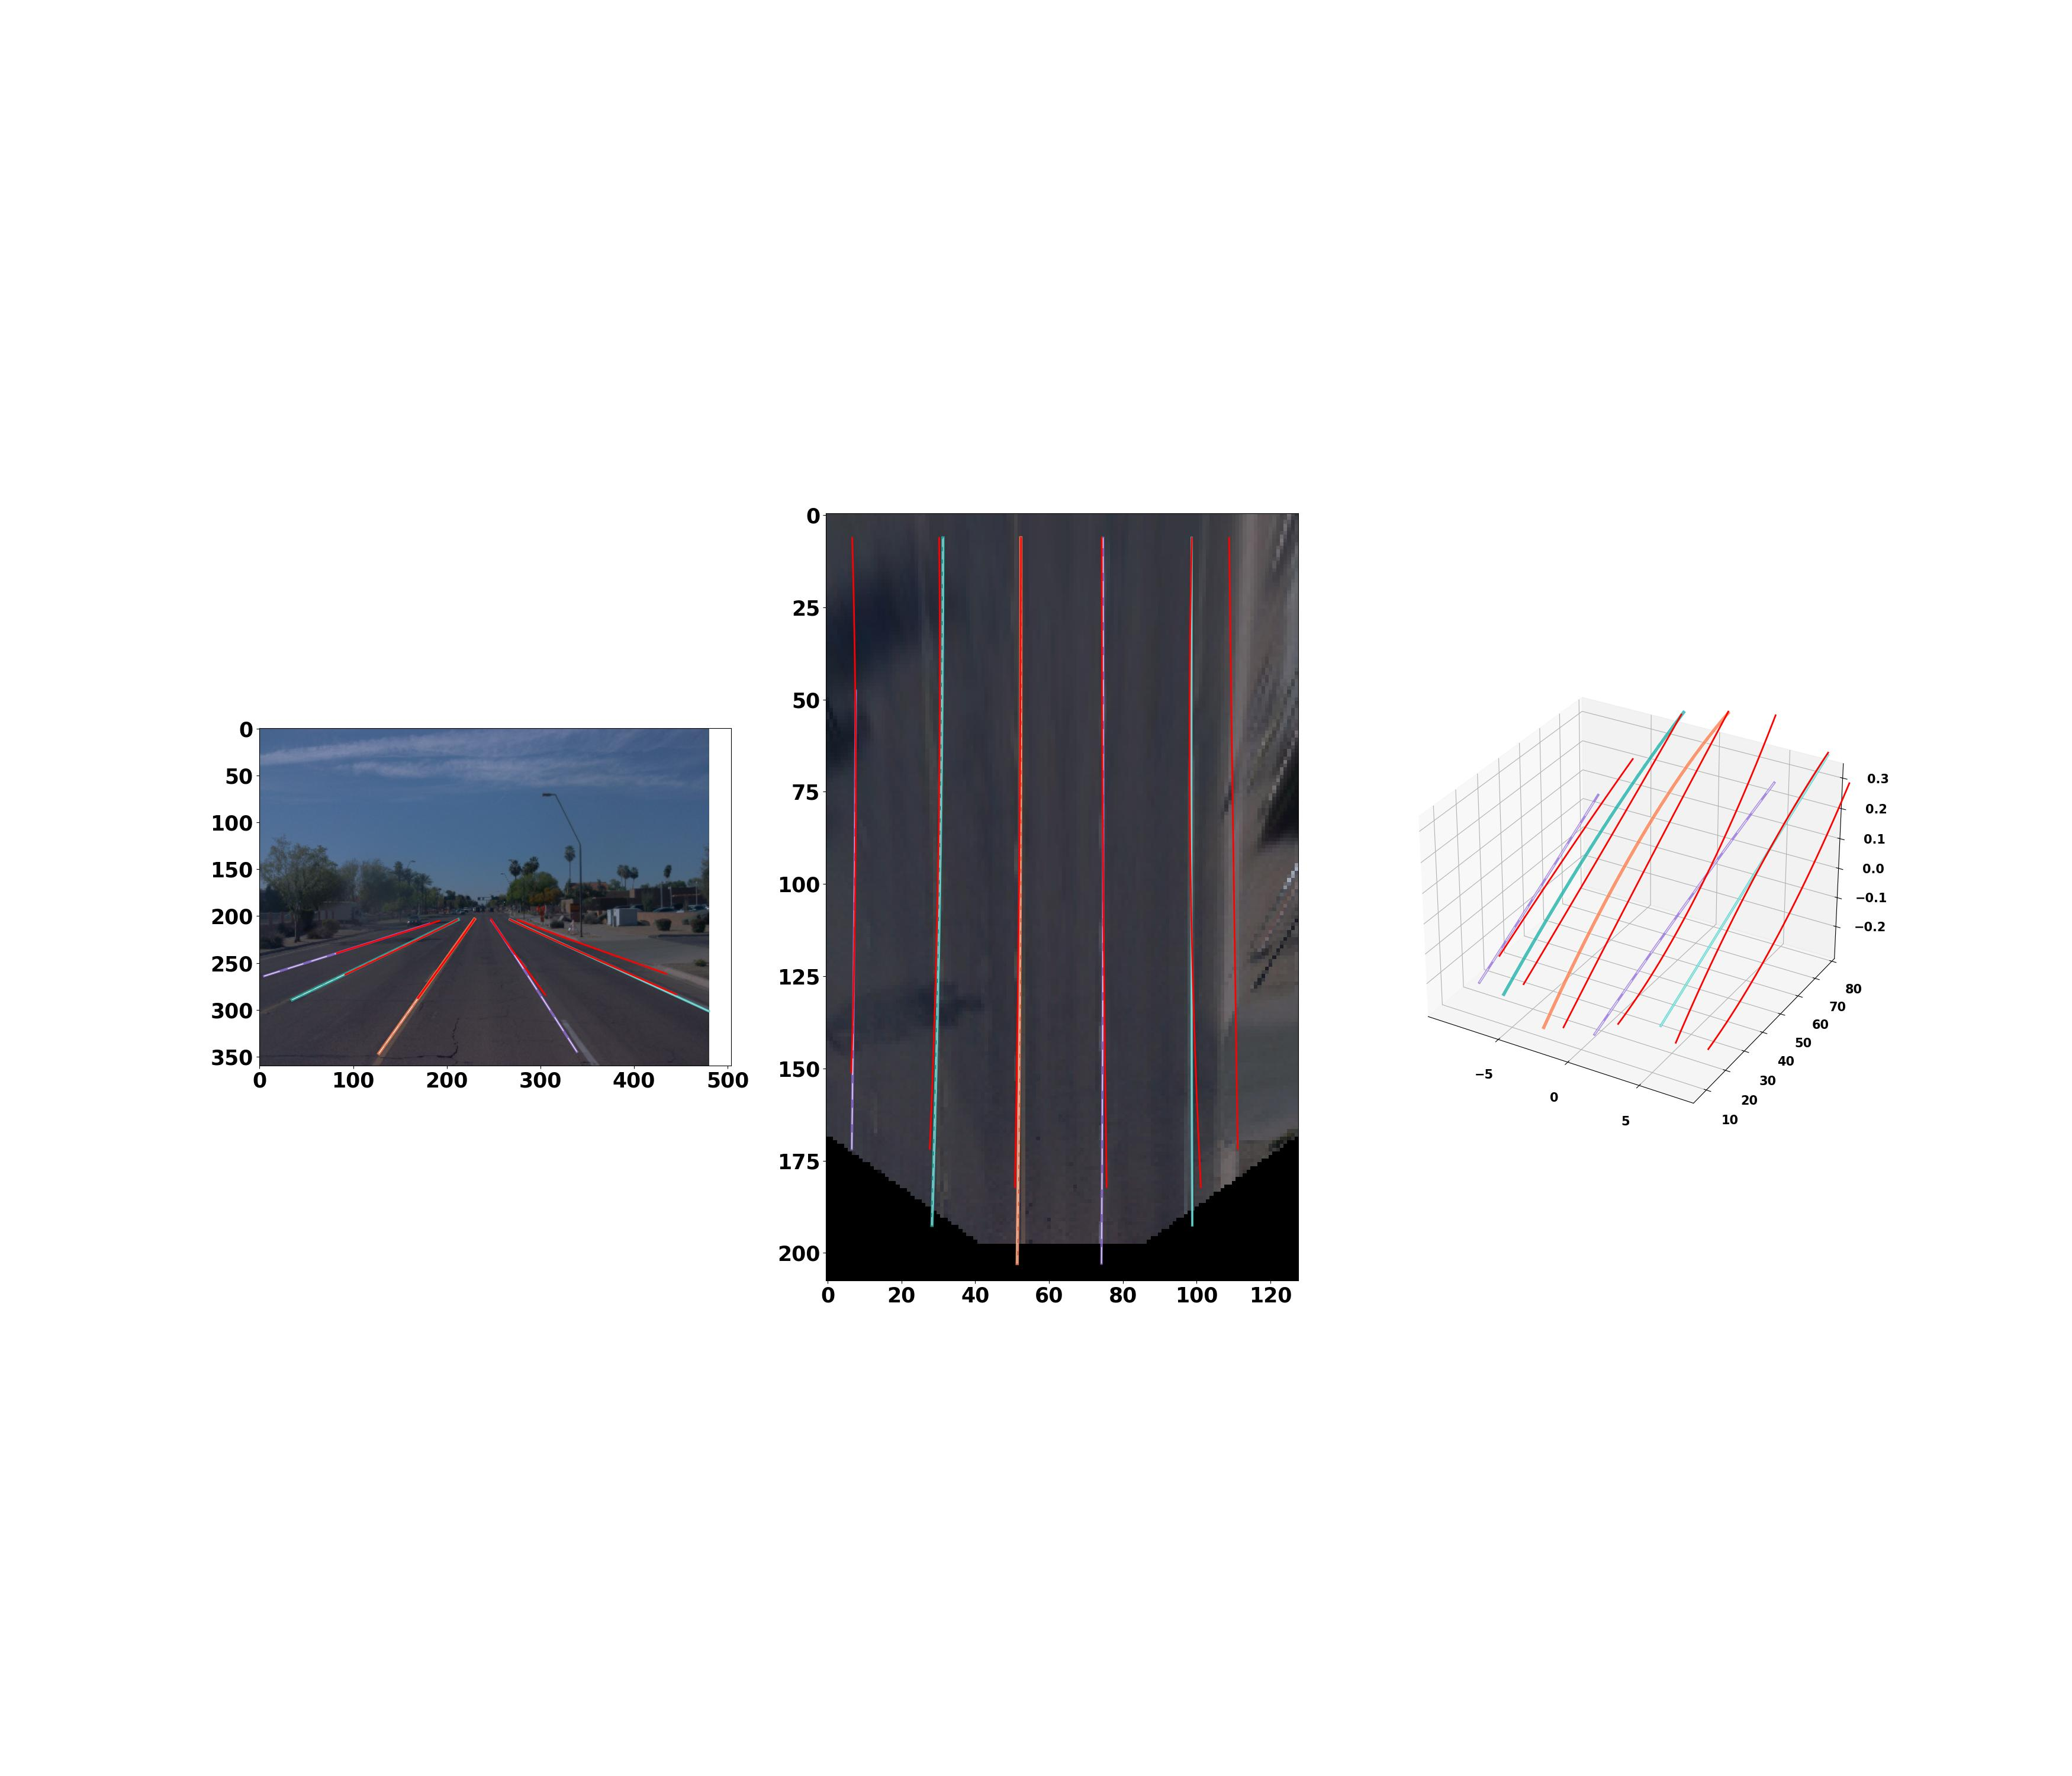

In [90]:
from IPython.display import Image, display
display(Image('/kaggle/working/output/eval_results/vis/validation_segment-11048712972908676520_545_000_565_000_with_camera_labels_152268469123823000.jpg'))

In [91]:
def forward_test(self, img, mask=None, img_metas=None, gt_project_matrix=None, **kwargs):
    gt_project_matrix = gt_project_matrix.squeeze(1)
    output, _ = self.encoder_decoder(img, mask, gt_project_matrix, **kwargs)

In [93]:
%%writefile /kaggle/working/Anchor3DLane/export_wrapper.py
import torch
import torch.nn as nn

class Anchor3DLaneExportWrapper(nn.Module):
    """Clean (img, mask, gt_project_matrix) -> proposals interface for ONNX export.
    Bypasses forward_test's squeeze(1) quirk since we control input shape directly."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, img, mask, gt_project_matrix):
        output, _ = self.model.encoder_decoder(img, mask, gt_project_matrix)
        proposals_list = self.model.nms(
            output['reg_proposals'], output['anchors'],
            self.model.test_cfg.nms_thres, self.model.test_cfg.conf_threshold,
            refine_vis=self.model.test_cfg.refine_vis,
            vis_thresh=self.model.test_cfg.vis_thresh
        )
        return proposals_list

Writing /kaggle/working/Anchor3DLane/export_wrapper.py


In [94]:
%%writefile /kaggle/working/Anchor3DLane/export_onnx.py
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ortools.graph import pywrapgraph  # MUST be first
import sys
sys.path.insert(0, '/kaggle/working/Anchor3DLane')

import numpy as np
import torch
from mmcv import Config
from mmcv.runner import load_checkpoint
from mmseg.models import build_lanedetector
from mmseg.datasets.tools.utils import projection_g2im
from export_wrapper import Anchor3DLaneExportWrapper

cfg = Config.fromfile('/kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_real.py')
model = build_lanedetector(cfg.model)
load_checkpoint(model, '/kaggle/working/output/real_run/latest.pth', map_location='cpu')
model.eval()

wrapper = Anchor3DLaneExportWrapper(model)

# approximate projection matrix from the model's own fixed camera assumptions
db = cfg.model.db_cfg
K = np.array(db['K'])
P_g2im = projection_g2im(np.radians(db['pitch']), db['cam_height'], K)   # (3,4)
gt_project_matrix = torch.tensor(P_g2im, dtype=torch.float32).unsqueeze(0)  # (1,3,4)

dummy_img = torch.randn(1, 3, 360, 480)
dummy_mask = torch.ones(1, 1, 360, 480)

torch.onnx.export(
    wrapper,
    (dummy_img, dummy_mask, gt_project_matrix),
    '/kaggle/working/output/anchor3dlane.onnx',
    input_names=['img', 'mask', 'gt_project_matrix'],
    output_names=['proposals'],
    opset_version=11,
    do_constant_folding=True,
    verbose=False
)
print("ONNX export completed")

Writing /kaggle/working/Anchor3DLane/export_onnx.py


In [96]:
!/kaggle/working/miniconda3/bin/conda create -y -n onnx_export python=3.9
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install torch==1.13.1 torchvision==0.14.1 --index-url https://download.pytorch.org/whl/cpu

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /kaggle/working/miniconda3/envs/onnx_export

  added / updated specs:
    - python=3.9


The following NEW packages will be INSTALLED:

  _libgcc_mutex      pkgs/main/linux-64::_libgcc_mutex-0.1-main 
  _openmp_mutex      pkgs/main/linux-64::_openmp_mutex-5.1-52_gnu 
  bzip2              pkgs/main/linux-64::bzip2-1.0.8-h5eee18b_6 
  ca-certificates    pkgs/main/linux-64::ca-certificates-2026.7.16-h06a4308_0 
  expat              pkgs/main/linux-64::expat-2.8.2-h7354ed3_1 
  ld_impl_linux-64   pkgs/main/linux-64::ld_impl_linux-64-2.44-h9e0c5a2_3 
  libexpat           pkgs/main/linux-64::libexpat-2.8.2-h7354ed3_1 
  libffi             pkgs/main/linux-64::libffi-3.4.8-h06d3fd0_3 
  libgcc             pkgs/main/linux-64::libgcc-15.2.0-h69a1729_8 
  libgcc-ng          pkgs/main/linux-64::libgcc-ng-15.2.0-h166f726_8 
  libnsl 

In [97]:
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install mmcv-full==1.7.1 -f https://download.openmmlab.com/mmcv/dist/cpu/torch1.13.0/index.html
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install -r /kaggle/working/Anchor3DLane/requirements.txt
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install geffnet onnx onnxruntime

Looking in links: https://download.openmmlab.com/mmcv/dist/cpu/torch1.13.0/index.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.0 MB/s  0:00:01m0:00:0100:01
  Using cached addict-2.4.0-py3-none-any.whl.metadata (1.0 kB)
  Using cached pyyaml-6.0.3-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached yapf-0.43.0-py3-none-any.whl.metadata (46 kB)
  Using cached platformdirs-4.4.0-py3-none-any.whl.metadata (12 kB)
  Using cached tomli-2.4.1-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 127.0 MB/s  0:00:00m0:00:0100:01
Using cached addict-2.4.0-py3-none-any.whl (3.8 kB)
Using cached pyyaml-6.0.3-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (750 kB)
Using cached yapf-0.43.0-py3-none-any.whl (256 kB)
Using cached platformdirs-4.4.0-py3-none-any.whl (18 kB)
Using cached tomli-2.4.1-py3-none-any.whl (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [98]:
!df -h /kaggle/working
!du -sh /kaggle/working/* 2>/dev/null | sort -rh

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   20G     0 100% /kaggle/working
11G	/kaggle/working/data
8.0G	/kaggle/working/miniconda3
785M	/kaggle/working/output
82M	/kaggle/working/Anchor3DLane
4.0K	/kaggle/working/test_dataset.py
4.0K	/kaggle/working/test_dataset_fixed.py


In [99]:
!ls -lh /kaggle/working/output/real_run/*.pth

-rw-r--r-- 1 root root 141M Jul 20 19:06 /kaggle/working/output/real_run/iter_59000.pth
-rw-r--r-- 1 root root 141M Jul 20 19:10 /kaggle/working/output/real_run/iter_59500.pth
-rw-r--r-- 1 root root 141M Jul 20 19:13 /kaggle/working/output/real_run/iter_60000.pth
lrwxrwxrwx 1 root root   14 Jul 20 19:13 /kaggle/working/output/real_run/latest.pth -> iter_60000.pth


In [100]:
!cd /kaggle/working/output/real_run && ls -1 iter_*.pth | sort -t_ -k2 -n | head -n -1 | xargs -r rm -v

removed 'iter_59000.pth'
removed 'iter_59500.pth'


In [101]:
!rm -rf /kaggle/working/miniconda3/envs/onnx_export
!df -h /kaggle/working

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   18G  1.8G  91% /kaggle/working


In [102]:
!du -sh /kaggle/working/data/OpenLane/cache_dense
!du -sh /kaggle/working/data/OpenLane/data_splits

2.7G	/kaggle/working/data/OpenLane/cache_dense
8.2G	/kaggle/working/data/OpenLane/data_splits


In [103]:
!rm -rf /kaggle/working/data/OpenLane/cache_dense
!rm -f /kaggle/working/data/OpenLane/data_splits/training.json /kaggle/working/data/OpenLane/data_splits/validation.json
!df -h /kaggle/working

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  7.0G   13G  36% /kaggle/working


In [104]:
!/kaggle/working/miniconda3/bin/conda create -y -n onnx_export python=3.9
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install torch==1.13.1 torchvision==0.14.1 --index-url https://download.pytorch.org/whl/cpu

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /kaggle/working/miniconda3/envs/onnx_export

  added / updated specs:
    - python=3.9


The following NEW packages will be INSTALLED:

  _libgcc_mutex      pkgs/main/linux-64::_libgcc_mutex-0.1-main 
  _openmp_mutex      pkgs/main/linux-64::_openmp_mutex-5.1-52_gnu 
  bzip2              pkgs/main/linux-64::bzip2-1.0.8-h5eee18b_6 
  ca-certificates    pkgs/main/linux-64::ca-certificates-2026.7.16-h06a4308_0 
  expat              pkgs/main/linux-64::expat-2.8.2-h7354ed3_1 
  ld_impl_linux-64   pkgs/main/linux-64::ld_impl_linux-64-2.44-h9e0c5a2_3 
  libexpat           pkgs/main/linux-64::libexpat-2.8.2-h7354ed3_1 
  libffi             pkgs/main/linux-64::libffi-3.4.8-h06d3fd0_3 
  libgcc             pkgs/main/linux-64::libgcc-15.2.0-h69a1729_8 
  libgcc-ng          pkgs/main/linux-64::libgcc-ng-15.2.0-h166f726_8 
  libnsl 

In [105]:
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install mmcv-full==1.7.1 -f https://download.openmmlab.com/mmcv/dist/cpu/torch1.13.0/index.html

Looking in links: https://download.openmmlab.com/mmcv/dist/cpu/torch1.13.0/index.html
  Using cached https://download.openmmlab.com/mmcv/dist/cpu/torch1.13.0/mmcv_full-1.7.1-cp39-cp39-manylinux1_x86_64.whl (24.6 MB)
  Using cached addict-2.4.0-py3-none-any.whl.metadata (1.0 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyyaml-6.0.3-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached yapf-0.43.0-py3-none-any.whl.metadata (46 kB)
  Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached platformdirs-4.4.0-py3-none-any.whl.metadata (12 kB)
  Using cached tomli-2.4.1-py3-none-any.whl.metadata (10 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl (73.8 MB)
Using cached addict-2.4.0-py3-none-any.whl (3.8 kB)
Using cached packaging-26.2-py3-none-any.whl (100 kB)
Using cached pyyaml-6.0.3-cp39-cp39-manylinux2014_x86_64.manyl

In [106]:
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install -r /kaggle/working/Anchor3DLane/requirements.txt
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install geffnet onnx onnxruntime

  Using cached matplotlib-3.5.1-cp39-cp39-manylinux_2_5_x86_64.manylinux1_x86_64.whl.metadata (6.7 kB)
  Using cached munkres-1.1.4-py2.py3-none-any.whl.metadata (980 bytes)
  Using cached numpy-1.22.3-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.0 kB)
  Using cached opencv_python-4.5.5.64-cp36-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached ortools-9.3.10497-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.4 kB)
  Using cached packaging-21.3-py3-none-any.whl.metadata (15 kB)
  Using cached pandas-1.5.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached Pillow-9.5.0-cp39-cp39-manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached prettytable-3.4.1-py3-none-any.whl.metadata (24 kB)
  Using cached scipy-1.7.3-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.2 kB)
  Using cached Shapely-1.8.4-cp39-cp39-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.

In [107]:
!cd /kaggle/working/Anchor3DLane && /kaggle/working/miniconda3/envs/onnx_export/bin/python setup.py develop

/kaggle/working/miniconda3/envs/onnx_export/lib/python3.9/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprecated.
!!

        ********************************************************************************
        Please consider removing the following classifiers in favor of a SPDX license expression:

        License :: OSI Approved :: Apache Software License

        See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
        ********************************************************************************

!!
  self._finalize_license_expression()
running develop
/kaggle/working/miniconda3/envs/onnx_export/lib/python3.9/site-packages/setuptools/_distutils/cmd.py:90: DevelopDeprecationWarning: develop command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``develop``.
        Instead, use 

In [113]:
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install "setuptools<66"
!/kaggle/working/miniconda3/envs/onnx_export/bin/pip install mmcv-full==1.6.2 --no-build-isolation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.7 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 80.9.0
    Uninstalling setuptools-80.9.0:
      Successfully uninstalled setuptools-80.9.0
  Using cached mmcv-full-1.6.2.tar.gz (575 kB)
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mmcv-full: filename=mmcv_full-1.6.2-cp39-cp39-linux_x86_64.whl size=1394863 sha256=33173c59ac27c1e0a878dd1c97e12f856b0fb7d73df505dcb060f04ea31f8bbb
  Stored in directory: /root/.cache/pip/wheels/04/cb/ce/05d993c0540d0a88979faa61a81bd512fc2c4b9ab1429edfaf
Successfully built mmcv-full


In [115]:
!grep -c "find_latest_checkpoint" /kaggle/working/Anchor3DLane/tools/train.py
!grep -c "^from .lane_datasets.once import ONCEDataset" /kaggle/working/Anchor3DLane/mmseg/datasets/__init__.py

2
0


In [117]:
!grep -n "from .ops.modules import MSDeformAttn" /kaggle/working/Anchor3DLane/mmseg/models/utils/__init__.py

12:from .ops.modules import MSDeformAttn


In [118]:
!sed -i "s/from .ops.modules import MSDeformAttn/try:\n    from .ops.modules import MSDeformAttn\nexcept (ImportError, ModuleNotFoundError):\n    MSDeformAttn = None/" /kaggle/working/Anchor3DLane/mmseg/models/utils/__init__.py
!cat /kaggle/working/Anchor3DLane/mmseg/models/utils/__init__.py

# Copyright (c) OpenMMLab. All rights reserved.
from .embed import PatchEmbed
from .inverted_residual import InvertedResidual, InvertedResidualV3
from .make_divisible import make_divisible
from .res_layer import ResLayer
from .se_layer import SELayer
from .self_attention_block import SelfAttentionBlock
from .shape_convert import (nchw2nlc2nchw, nchw_to_nlc, nlc2nchw2nlc,
                            nlc_to_nchw)
from .up_conv_block import UpConvBlock
from .misc import get_paddings_indicator
try:
    from .ops.modules import MSDeformAttn
except (ImportError, ModuleNotFoundError):
    MSDeformAttn = None

__all__ = [
    'ResLayer', 'SelfAttentionBlock', 'make_divisible', 'InvertedResidual',
    'UpConvBlock', 'InvertedResidualV3', 'SELayer', 'PatchEmbed',
    'nchw_to_nlc', 'nlc_to_nchw', 'nchw2nlc2nchw', 'nlc2nchw2nlc', 'get_paddings_indicator',
    'MSDeformAttn'
]


In [120]:
!sed -i "s/opset_version=11/opset_version=16/" /kaggle/working/Anchor3DLane/export_onnx.py
!grep opset_version /kaggle/working/Anchor3DLane/export_onnx.py

    opset_version=16,


In [121]:
!/kaggle/working/miniconda3/envs/onnx_export/bin/python /kaggle/working/Anchor3DLane/export_onnx.py

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
anchor: 4431
/kaggle/working/Anchor3DLane/mmseg/models/backbones/resnet.py:431: UserWarning: DeprecationWarning: pretrained is a deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is a deprecated, '
load checkpoint from local path: /kaggle/working/output/real_run/latest.pth
/kaggle/working/Anchor3DLane/mmseg/models/lane_detector/anchor_3dlane.py:240: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert h == self.feat_size[0] and w == self.feat_size[1]
/kaggle/working/Anchor3DLane/mmseg/models/lane_detector/anchor_3dlane.py:328: TracerWarning: Converting a tensor to a NumPy array might cause the trace to be incorrect. We can't record the data flow of Python values, so this

In [122]:
%%writefile /kaggle/working/Anchor3DLane/verify_onnx.py
import numpy as np
import onnxruntime as ort

sess = ort.InferenceSession('/kaggle/working/output/anchor3dlane.onnx')

print("Inputs:", [(i.name, i.shape) for i in sess.get_inputs()])
print("Outputs:", [(o.name, o.shape) for o in sess.get_outputs()])

dummy_img = np.random.randn(1, 3, 360, 480).astype(np.float32)
dummy_mask = np.ones((1, 1, 360, 480), dtype=np.float32)
dummy_proj = np.random.randn(1, 3, 4).astype(np.float32)

outputs = sess.run(None, {
    'img': dummy_img,
    'mask': dummy_mask,
    'gt_project_matrix': dummy_proj
})
print("Inference succeeded")
print("Output shapes:", [o.shape if hasattr(o, 'shape') else type(o) for o in outputs])

Writing /kaggle/working/Anchor3DLane/verify_onnx.py


In [123]:
!/kaggle/working/miniconda3/envs/onnx_export/bin/python /kaggle/working/Anchor3DLane/verify_onnx.py

Inputs: [('img', [1, 3, 360, 480]), ('mask', [1, 1, 360, 480])]
Outputs: [('proposals', [0, 86]), ('1139', [0, 65])]
Traceback (most recent call last):
  File "/kaggle/working/Anchor3DLane/verify_onnx.py", line 13, in <module>
    outputs = sess.run(None, {
  File "/kaggle/working/miniconda3/envs/onnx_export/lib/python3.9/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py", line 220, in run
    return self._sess.run(output_names, input_feed, run_options)
onnxruntime.capi.onnxruntime_pybind11_state.InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Invalid input name: gt_project_matrix


In [124]:
!ls -lh /kaggle/working/output/anchor3dlane.onnx

-rw-r--r-- 1 root root 52M Jul 20 20:42 /kaggle/working/output/anchor3dlane.onnx


In [131]:
!grep -n "model.eval()" /kaggle/working/Anchor3DLane/export_onnx.py

18:model.eval()


In [132]:
!sed -i "/model.eval()/a model.test_cfg.conf_threshold = 0.0\nmodel.test_cfg.nms_thres = 0.0" /kaggle/working/Anchor3DLane/export_onnx.py
!cat /kaggle/working/Anchor3DLane/export_onnx.py

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ortools.graph import pywrapgraph  # MUST be first
import sys
sys.path.insert(0, '/kaggle/working/Anchor3DLane')

import numpy as np
import torch
from mmcv import Config
from mmcv.runner import load_checkpoint
from mmseg.models import build_lanedetector
from mmseg.datasets.tools.utils import projection_g2im
from export_wrapper import Anchor3DLaneExportWrapper

cfg = Config.fromfile('/kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_real.py')
model = build_lanedetector(cfg.model)
load_checkpoint(model, '/kaggle/working/output/real_run/latest.pth', map_location='cpu')
model.eval()
model.test_cfg.conf_threshold = 0.0
model.test_cfg.nms_thres = 0.0

wrapper = Anchor3DLaneExportWrapper(model)

# approximate projection matrix from the model's own fixed camera assumptions
db = cfg.model.db_cfg
K = np.array(db['K'])
P_g2im = projection_g2im(np.radians(db['pitch']), db['cam_height'], K)   # (3,4)
gt_project_matrix = torch.tensor

In [133]:
!/kaggle/working/miniconda3/envs/onnx_export/bin/python /kaggle/working/Anchor3DLane/export_onnx.py

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
anchor: 4431
/kaggle/working/Anchor3DLane/mmseg/models/backbones/resnet.py:431: UserWarning: DeprecationWarning: pretrained is a deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is a deprecated, '
load checkpoint from local path: /kaggle/working/output/real_run/latest.pth
/kaggle/working/Anchor3DLane/mmseg/models/lane_detector/anchor_3dlane.py:240: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert h == self.feat_size[0] and w == self.feat_size[1]
/kaggle/working/Anchor3DLane/mmseg/models/lane_detector/anchor_3dlane.py:328: TracerWarning: Converting a tensor to a NumPy array might cause the trace to be incorrect. We can't record the data flow of Python values, so this

In [140]:
%%writefile /kaggle/working/Anchor3DLane/test_onnx_image_v2.py
import os
os.environ["MPLBACKEND"] = "Agg"
import matplotlib
matplotlib.use('Agg')

import sys
sys.path.insert(0, '/kaggle/working/Anchor3DLane')
import numpy as np
import cv2
import torch
import torch.nn.functional as F
import onnxruntime as ort

IMG_PATH = '/kaggle/working/data/OpenLane/images/validation/segment-11048712972908676520_545_000_565_000_with_camera_labels/152268469123823000.jpg'
ANCHOR_LEN = 20
ANCHOR_Y_STEPS = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

img_norm_mean = np.array([123.675, 116.28, 103.53], dtype=np.float32)
img_norm_std  = np.array([58.395, 57.12, 57.375], dtype=np.float32)

raw = cv2.imread(IMG_PATH)
resized = cv2.resize(raw, (480, 360))
img = resized[:, :, ::-1].astype(np.float32)
img = (img - img_norm_mean) / img_norm_std
img = img.transpose(2, 0, 1)[None, ...].astype(np.float32)
mask = np.ones((1, 1, 360, 480), dtype=np.float32)

sess = ort.InferenceSession('/kaggle/working/output/anchor3dlane.onnx')
proposals_arr = sess.run(None, {'img': img, 'mask': mask})[0]
proposals = torch.from_numpy(proposals_arr)
print("Raw proposals shape:", proposals.shape)

logits = F.softmax(proposals[:, 5 + 3 * ANCHOR_LEN:], dim=1)
score = 1 - logits[:, 0]
proposals[:, 1] = score
proposals[:, 5 + 3 * ANCHOR_LEN:] = logits

print("Confidence score stats -> max:", score.max().item(), "mean:", score.mean().item(), "count>0.2:", (score > 0.2).sum().item())

vis = proposals[:, 5 + ANCHOR_LEN * 2 : 5 + ANCHOR_LEN * 3] > 0
vis_counts = vis.sum(dim=1)
print("Visibility counts per anchor -> max:", vis_counts.max().item(), "mean:", vis_counts.float().mean().item())
print("Anchors with >=2 visible points:", (vis_counts >= 2).sum().item())

ys = np.array(ANCHOR_Y_STEPS, dtype=np.float32)
lanes, probs = [], []
for lane in proposals.numpy():
    lane_xs = lane[5:5 + ANCHOR_LEN]
    lane_vis = (lane[5 + ANCHOR_LEN * 2 : 5 + ANCHOR_LEN * 3]) > 0
    if lane_vis.sum() < 2:
        continue
    lanes.append(lane_xs[lane_vis])
    probs.append(lane[1])

print("Decoded lane count (vis>=2 filter applied):", len(lanes))
print("Top probs:", sorted(probs, reverse=True)[:10])

Writing /kaggle/working/Anchor3DLane/test_onnx_image_v2.py


In [141]:
!MPLBACKEND=Agg /kaggle/working/miniconda3/envs/onnx_export/bin/python /kaggle/working/Anchor3DLane/test_onnx_image_v2.py

Raw proposals shape: torch.Size([4431, 86])
Confidence score stats -> max: nan mean: nan count>0.2: 0
Visibility counts per anchor -> max: 20 mean: 0.06319115310907364
Anchors with >=2 visible points: 14
Decoded lane count (vis>=2 filter applied): 14
Top probs: [0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692]


In [142]:
%%writefile /kaggle/working/Anchor3DLane/export_onnx_real_calib.py
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ortools.graph import pywrapgraph
import sys, json
sys.path.insert(0, '/kaggle/working/Anchor3DLane')

import numpy as np
import torch
from mmcv import Config
from mmcv.runner import load_checkpoint
from mmseg.models import build_lanedetector
from mmseg.datasets.tools.utils import projection_g2im_extrinsic
from export_wrapper import Anchor3DLaneExportWrapper

TARGET_FILE_SUFFIX = "152268469123823000.jpg"   # our test image

# find the real calibration for this exact image in the validation annotations
val_json_path = '/kaggle/working/data/OpenLane/data_splits/validation.json'
record = None
with open(val_json_path) as f:
    for line in f:
        d = json.loads(line)
        if d['file_path'].endswith(TARGET_FILE_SUFFIX):
            record = d
            break

assert record is not None, "Couldn't find this image in validation.json"
extrinsic = np.array(record['extrinsic'])
intrinsic = np.array(record['intrinsic'])
P_g2im = projection_g2im_extrinsic(extrinsic, intrinsic)
print("Real per-frame projection matrix:\n", P_g2im)

cfg = Config.fromfile('/kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_real.py')
model = build_lanedetector(cfg.model)
load_checkpoint(model, '/kaggle/working/output/real_run/latest.pth', map_location='cpu')
model.eval()
model.test_cfg.conf_threshold = 0.0
model.test_cfg.nms_thres = 0.0

wrapper = Anchor3DLaneExportWrapper(model)
gt_project_matrix = torch.tensor(P_g2im, dtype=torch.float32).unsqueeze(0)
dummy_img = torch.randn(1, 3, 360, 480)
dummy_mask = torch.ones(1, 1, 360, 480)

torch.onnx.export(
    wrapper,
    (dummy_img, dummy_mask, gt_project_matrix),
    '/kaggle/working/output/anchor3dlane_realcalib.onnx',
    input_names=['img', 'mask', 'gt_project_matrix'],
    output_names=['proposals', 'anchors'],
    opset_version=16,
    do_constant_folding=True,
    verbose=False
)
print("Export with REAL calibration completed")

Writing /kaggle/working/Anchor3DLane/export_onnx_real_calib.py


In [144]:
!cd /kaggle/working/Anchor3DLane && /kaggle/working/miniconda3/envs/onnx_export/bin/python tools/convert_datasets/openlane.py /kaggle/working/data/OpenLane --merge
!wc -c /kaggle/working/data/OpenLane/data_splits/validation.json

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
1986039149 /kaggle/working/data/OpenLane/data_splits/validation.json


In [145]:
!/kaggle/working/miniconda3/envs/onnx_export/bin/python /kaggle/working/Anchor3DLane/export_onnx_real_calib.py

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
Real per-frame projection matrix:
 [[ 2.06947210e+03 -4.87715457e+00  9.81156838e+02 -5.27154780e+03]
 [-7.39575587e+00  2.07902635e+03  6.67462420e+02 -1.35057705e+03]
 [-1.26271973e-02 -4.02539017e-03  9.99912171e-01 -2.09626674e+00]]
anchor: 4431
/kaggle/working/Anchor3DLane/mmseg/models/backbones/resnet.py:431: UserWarning: DeprecationWarning: pretrained is a deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is a deprecated, '
load checkpoint from local path: /kaggle/working/output/real_run/latest.pth
/kaggle/working/Anchor3DLane/mmseg/models/lane_detector/anchor_3dlane.py:240: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert h == self.feat_size[0] and w == self.

In [146]:
!sed -i "s|anchor3dlane.onnx|anchor3dlane_realcalib.onnx|" /kaggle/working/Anchor3DLane/test_onnx_image_v2.py
!MPLBACKEND=Agg /kaggle/working/miniconda3/envs/onnx_export/bin/python /kaggle/working/Anchor3DLane/test_onnx_image_v2.py

Raw proposals shape: torch.Size([4431, 86])
Confidence score stats -> max: 0.01710069179534912 mean: 0.01710069365799427 count>0.2: 0
Visibility counts per anchor -> max: 20 mean: 20.0
Anchors with >=2 visible points: 4431
Decoded lane count (vis>=2 filter applied): 4431
Top probs: [0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692, 0.017100692]


In [147]:
%%writefile /kaggle/working/Anchor3DLane/compare_pytorch_onnx.py
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ortools.graph import pywrapgraph
import sys, json
sys.path.insert(0, '/kaggle/working/Anchor3DLane')

import numpy as np
import cv2
import torch
import torch.nn.functional as F
from mmcv import Config
from mmcv.runner import load_checkpoint
from mmseg.models import build_lanedetector
from mmseg.datasets.tools.utils import projection_g2im_extrinsic

TARGET_FILE_SUFFIX = "152268469123823000.jpg"
IMG_PATH = '/kaggle/working/data/OpenLane/images/validation/segment-11048712972908676520_545_000_565_000_with_camera_labels/152268469123823000.jpg'

val_json_path = '/kaggle/working/data/OpenLane/data_splits/validation.json'
record = None
with open(val_json_path) as f:
    for line in f:
        d = json.loads(line)
        if d['file_path'].endswith(TARGET_FILE_SUFFIX):
            record = d
            break
extrinsic = np.array(record['extrinsic'])
intrinsic = np.array(record['intrinsic'])
P_g2im = projection_g2im_extrinsic(extrinsic, intrinsic)

cfg = Config.fromfile('/kaggle/working/Anchor3DLane/configs/openlane/anchor3dlane_real.py')
model = build_lanedetector(cfg.model)
load_checkpoint(model, '/kaggle/working/output/real_run/latest.pth', map_location='cpu')
model.eval()
model.test_cfg.conf_threshold = 0.0
model.test_cfg.nms_thres = 0.0

img_norm_mean = np.array([123.675, 116.28, 103.53], dtype=np.float32)
img_norm_std  = np.array([58.395, 57.12, 57.375], dtype=np.float32)
raw = cv2.imread(IMG_PATH)
resized = cv2.resize(raw, (480, 360))
img_np = resized[:, :, ::-1].astype(np.float32)
img_np = (img_np - img_norm_mean) / img_norm_std
img_t = torch.from_numpy(img_np.transpose(2, 0, 1)[None, ...].astype(np.float32))
mask_t = torch.ones(1, 1, 360, 480)
proj_t = torch.tensor(P_g2im, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    output, _ = model.encoder_decoder(img_t, mask_t, proj_t)
    proposals_list = model.nms(output['reg_proposals'], output['anchors'],
                                model.test_cfg.nms_thres, model.test_cfg.conf_threshold,
                                refine_vis=model.test_cfg.refine_vis, vis_thresh=model.test_cfg.vis_thresh)

proposals = proposals_list[0][0]  # (proposal, anchor) tuple, take proposal
print("PyTorch proposals shape:", proposals.shape)

ANCHOR_LEN = 20
logits = F.softmax(proposals[:, 5 + 3*ANCHOR_LEN:], dim=1)
score = 1 - logits[:, 0]
vis = proposals[:, 5+ANCHOR_LEN*2 : 5+ANCHOR_LEN*3] > 0
vis_counts = vis.sum(dim=1)

print("PyTorch confidence -> max:", score.max().item(), "mean:", score.mean().item(), "unique values:", len(torch.unique(score)))
print("PyTorch visibility counts -> max:", vis_counts.max().item(), "mean:", vis_counts.float().mean().item(), "unique values:", len(torch.unique(vis_counts)))

Writing /kaggle/working/Anchor3DLane/compare_pytorch_onnx.py


In [148]:
!/kaggle/working/miniconda3/envs/lane3d/bin/python /kaggle/working/Anchor3DLane/compare_pytorch_onnx.py

anchor: 4431
/kaggle/working/Anchor3DLane/mmseg/models/backbones/resnet.py:431: UserWarning: DeprecationWarning: pretrained is a deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is a deprecated, '
load checkpoint from local path: /kaggle/working/output/real_run/latest.pth
/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/torch/_tensor.py:575: UserWarning: floor_divide is deprecated, and will be removed in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values.
To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor'). (Triggered internally at  ../aten/src/ATen/native/BinaryOps.cpp:467.)
  return torch.floor_divide(self, other)
/kaggle/working/miniconda3/envs/lane3d/lib/python3.9/site-packages/torch/nn/functional.py:3981: UserWarning: Default gr

In [1]:
!sed -i "/model.test_cfg.conf_threshold = 0.0/d; /model.test_cfg.nms_thres = 0.0/d" /kaggle/working/Anchor3DLane/export_onnx_real_calib.py
!grep -n "conf_threshold\|nms_thres" /kaggle/working/Anchor3DLane/export_onnx_real_calib.py

sed: can't read /kaggle/working/Anchor3DLane/export_onnx_real_calib.py: No such file or directory
grep: /kaggle/working/Anchor3DLane/export_onnx_real_calib.py: No such file or directory
